## Part 1

In [1]:
import matplotlib.pyplot as plt

In [ ]:
#task 1: data preprocessing function

import pandas as pd
import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords as stop
from nltk.stem.snowball import SnowballStemmer
import warnings

#ignore warnings
warnings.filterwarnings('ignore')

import numpy as np

url = "https://raw.githubusercontent.com/several27/FakeNewsCorpus/master/news_sample.csv"
df = pd.read_csv(url)

def data_preprocessing(df):

    df = df.dropna(subset=['content'])
    #text tokenization
    df['tokenized_words'] = df['content'].apply(nltk.word_tokenize)

    complete_l_o_w = []
    for i in range(len(df['tokenized_words'])):
        complete_l_o_w.extend(df['tokenized_words'].iloc[i])

    print(len(complete_l_o_w))

    #get English stopwords 
    stop_words = set(stop.words('english')) #nltk has a list of stopwords

    #removal of stopwords
    for i in range(len(df['tokenized_words'])):
        df['tokenized_words'][i] = [word for word in df['tokenized_words'][i] if word not in stop_words]

    complete_l_o_w_after = []
    for i in range(len(df['tokenized_words'])):
        complete_l_o_w_after.extend(df['tokenized_words'].iloc[i])
    
    print(len(complete_l_o_w_after))

    #
    vocab_before = list(dict.fromkeys(complete_l_o_w))

    #
    vocab_after = list(dict.fromkeys(complete_l_o_w_after))

    #calculate reduction rate
    reduction_rate1 = len(vocab_after)/len(vocab_before)

    #word stemming
    stemmer = SnowballStemmer("english")
    for i in range(len(df['tokenized_words'])):
        df['tokenized_words'][i] = [stemmer.stem(word) for word in df['tokenized_words'][i]]
        
    complete_l_o_w_final = []
    for i in range(len(df['tokenized_words'])):
        complete_l_o_w_final.extend(df['tokenized_words'].iloc[i])
    
    vocab_final = list(dict.fromkeys(complete_l_o_w_final))

    reduction_rate2 = len(vocab_final)/len(vocab_before)

    print(f'Reduction rate after removal of stopwords: {reduction_rate1}\nReduction rate after stemming (compared to vocab before removal of stopwords): {reduction_rate2}')

    return



data_preprocessing(df)


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\asger\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\asger\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asger\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\asger\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


198366
129867
Reduction rate after removal of stopwords: 0.9931255072325392
Reduction rate after stemming (compared to vocab before removal of stopwords): 0.5980331312359766
['sometim', 'power', 'christma', 'make', 'wild', 'wonder', 'thing', '.', 'you', 'need', 'believ', 'holi', 'triniti', 'believ', 'posit', 'power', 'good', 'other', '.', 'the', 'simpl', 'act', 'give', 'without', 'receiv', 'lost', 'mani', 'us', 'day', ',', 'worri', 'money', 'success', 'hold', 'us', 'back', 'give', 'other', 'need', '.', 'one', 'congreg', 'ohio', 'move', 'action', 'power', 'sermon', 'given', 'church', 'christma', 'eve', '.', 'the', 'pastor', 'grand', 'lake', 'unit', 'methodist', 'church', 'celina', ',', 'ohio', 'gave', 'emot', 'sermon', 'import', 'understand', 'messag', 'jesus', '.', 'for', 'mani', 'religi', 'peopl', 'messag', 'jesus', 'help', 'other', ',', 'make', 'sure', 'peopl', 'suffer', 'get', 'help', 'need', 'enjoy', 'life', 'littl', 'bit', '.', 'the', 'sermon', 'realli', 'generos', 'look', 'like',

In [3]:
# Download data from huggingface repositiory (we uploaded the data first).
from huggingface_hub import hf_hub_download

file_path = hf_hub_download(
    repo_id="MikkelPraestegaard/GDS_final_assignment",
    filename="subset_FakeNews.zip",
    repo_type="dataset",
)

In [4]:
# Read in the data
df1 = pd.read_csv(file_path)

In [5]:
data_preprocessing(df1)

KeyboardInterrupt: 

In [ ]:
# Michel

In [ ]:
# Mikkel
print('HEJ!!!')


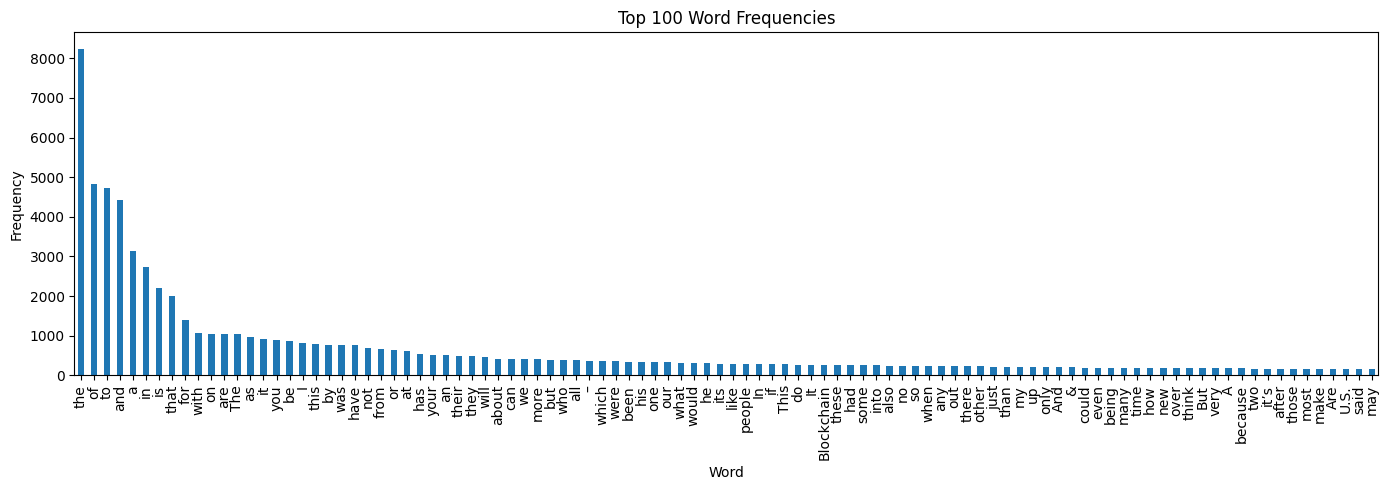

content
the     8244
of      4826
to      4722
and     4414
a       3141
        ... 
make     156
Are      156
U.S.     152
said     148
may      148
Name: count, Length: 100, dtype: int64

In [40]:
# Asger
def visualize_top_words(
    df: pd.DataFrame,
    token_col: str,
    top_n: int = 10_000,
    loglog: bool = True
):
    """
    df        : cleaned Pandas DataFrame
    token_col: column containing tokenized text (list of tokens per row)
    top_n    : number of most frequent words to visualize 
    
    If top_n <= 100 there will be put labels on for the x axis.
    """
    label_limit = 100
    # Flatten tokens
    col = df[token_col]
    
    if isinstance(col.iloc[0], str):
        tokens = col.str.split().explode()
    else:
        tokens = col.explode()
    
    tokens = tokens.dropna()
    counts = tokens.value_counts().head(top_n)

    # Plot
    plt.figure(figsize=(14, 5))

    if loglog:
        ranks = np.arange(1, len(counts) + 1)
        plt.loglog(ranks, counts.values)
        plt.xlabel("Rank")
        plt.ylabel("Frequency")
        plt.title("Word Frequency (Log-Log Scale)")
    else:
        if top_n <= label_limit:
            counts.plot(kind="bar")
            plt.xlabel("Word")
        else:
            plt.plot(counts.values)
            plt.xlabel("Rank")
        plt.ylabel("Frequency")
        plt.title(f"Top {len(counts)} Word Frequencies")

    plt.tight_layout()
    plt.show()

    return counts

visualize_top_words(df,'content',100,loglog=False)

In [ ]:
# Mikkel